In [ ]:
EXPERIMENT_NAME = 'test'

# Experiment: `L3`

**What varies:** Describe what this experiment tests (e.g. "lower beta with spectral loss").

**Hypothesis:** What you expect to see.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time
from datetime import datetime
from sklearn.model_selection import train_test_split

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# ============================================================
# EXPERIMENT SETUP — config, data, dataloaders
# ============================================================
EXPERIMENT_NAME = 'temporary'
DRY_RUN = False

training_kwargs = dict(
    lr=1e-3,
    epochs=300,
    batch_size=256,
    patience=100,
)

STATE_COLS = ["RAS_s", "RAF_s", "MEK_s", "NFB_s", "ERK_s"]

# --- Data: flatten trajectories into individual timepoints ---
df = pd.read_parquet("synthetic_EGFR_data.parquet")
states = np.stack([np.concatenate(df[c].values) for c in STATE_COLS], axis=1).astype(np.float32)

# split by trajectory, then flatten
traj_ids = np.arange(len(df))
tr_ids, te_ids = train_test_split(traj_ids, test_size=0.2, random_state=42)
tr_ids, va_ids = train_test_split(tr_ids, test_size=0.125, random_state=42)

traj_len = len(df[STATE_COLS[0]].iloc[0])
def ids_to_mask(ids):
    idx = np.concatenate([np.arange(i * traj_len, (i + 1) * traj_len) for i in ids])
    return idx

train_states = torch.tensor(states[ids_to_mask(tr_ids)])
val_states = torch.tensor(states[ids_to_mask(va_ids)])
test_states = torch.tensor(states[ids_to_mask(te_ids)])

BS = training_kwargs["batch_size"]
train_ds = TensorDataset(train_states, train_states)
val_ds = TensorDataset(val_states, val_states)
test_ds = TensorDataset(test_states, test_states)

if DRY_RUN:
    n_dry = 1024
    train_ds = Subset(train_ds, range(min(n_dry, len(train_ds))))
    val_ds = Subset(val_ds, range(min(n_dry, len(val_ds))))
    test_ds = Subset(test_ds, range(min(n_dry, len(test_ds))))

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BS, shuffle=False)

print(f"Device: {device} | DRY_RUN: {DRY_RUN}")
print(f"State dim: {states.shape[1]} | Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")
print(f"Batch shape: {next(iter(train_loader))[0].shape}")

Device: mps | DRY_RUN: False
State dim: 5 | Train: 700000  Val: 100000  Test: 200000
Batch shape: torch.Size([256, 5])


---
# Model

In [24]:
from model.dl import AutoEncoder

In [ ]:
model = AutoEncoder(
    input_dim=len(STATE_COLS),
    hidden_dims=4,
    latent_dim=3,
).to(device)

print(f"Model: {model.__class__.__name__} | Params: {sum(p.numel() for p in model.parameters()):,}")

Model: AutoEncoder | Params: 9,480


---
# Training

In [26]:
def train(model, train_loader, val_loader, cfg):
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    best_val = float("inf")
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    epochs = 5 if DRY_RUN else cfg["epochs"]
    patience = 3 if DRY_RUN else cfg["patience"]
    ckpt_path = f"best_model_{EXPERIMENT_NAME}.pt"

    for epoch in range(epochs):
        model.train()
        t_losses = []
        for x, target in train_loader:
            x, target = x.to(device), target.to(device)
            recon, z = model(x)
            loss = model.loss(recon, target)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_losses.append(loss.item())

        model.eval()
        v_losses = []
        with torch.no_grad():
            for x, target in val_loader:
                x, target = x.to(device), target.to(device)
                recon, z = model(x)
                loss = model.loss(recon, target)
                v_losses.append(loss.item())

        t_mean = np.mean(t_losses)
        v_mean = np.mean(v_losses)
        history["train_loss"].append(t_mean)
        history["val_loss"].append(v_mean)

        scheduler.step(v_mean)

        if v_mean < best_val:
            best_val = v_mean
            wait = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Train: {t_mean:.6f} | Val: {v_mean:.6f}")

    model.load_state_dict(torch.load(ckpt_path, weights_only=True))
    os.remove(ckpt_path)
    return history

In [27]:
train_start = datetime.now()
t0 = time.time()

history = train(model, train_loader, val_loader, training_kwargs)

train_elapsed = time.time() - t0
print(f"\nTraining: {train_start.strftime('%Y-%m-%d %H:%M:%S')} | {train_elapsed:.0f}s ({train_elapsed/60:.1f} min)")

Epoch   0 | Train: 0.001235 | Val: 0.000018


KeyboardInterrupt: 

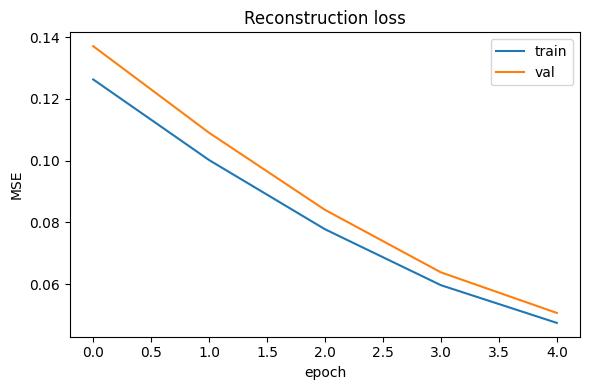

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_title("Reconstruction loss")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE")
ax.legend()
plt.tight_layout()
plt.show()

---
# Evaluation

In [ ]:
from eval_ae import evaluate

test_states_np = test_states.numpy() if isinstance(test_states, torch.Tensor) else test_states
test_traj_lengths = np.full(len(te_ids), traj_len)
state_names = [c.replace("_s", "") for c in STATE_COLS]

result = evaluate(
    model=model,
    states=test_states_np,
    traj_lengths=test_traj_lengths,
    state_names=state_names,
    name=EXPERIMENT_NAME,
)
result.summary()

=== ae_states (2026-03-17 11:37:37) ===
  Samples        : 200000
  Latent dim     : 3
  MSE overall    : 0.050302
  MSE per state  :
       RAS: 0.072347
       RAF: 0.003415
       MEK: 0.012421
       NFB: 0.086759
       ERK: 0.076560



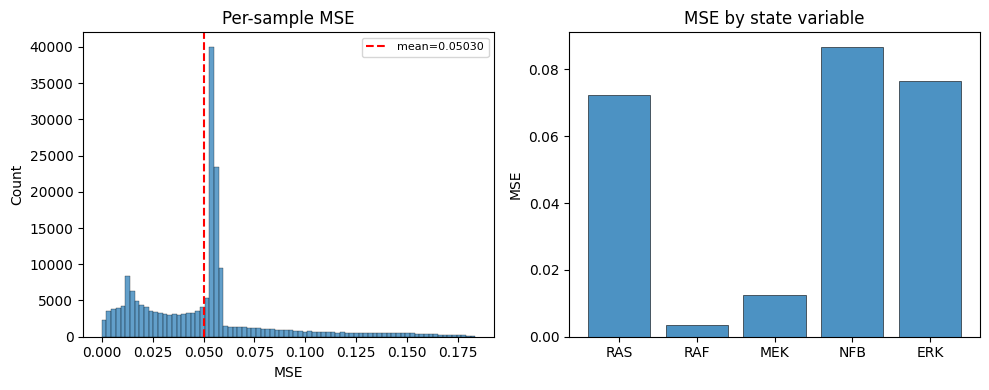

In [ ]:
result.figures["reconstruction_error"]

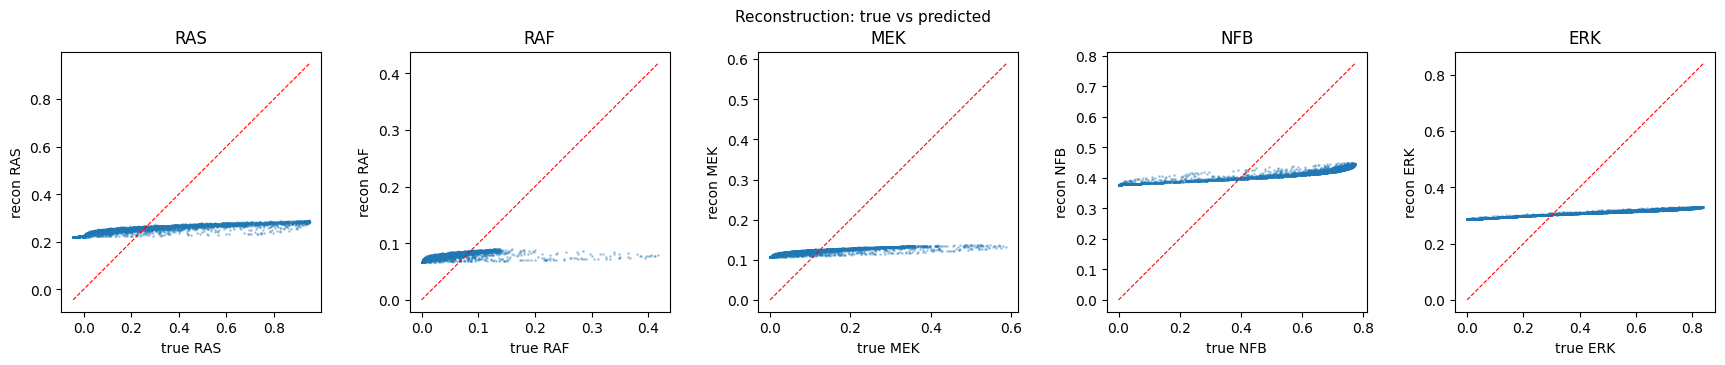

In [ ]:
result.figures["reconstruction_scatter"]

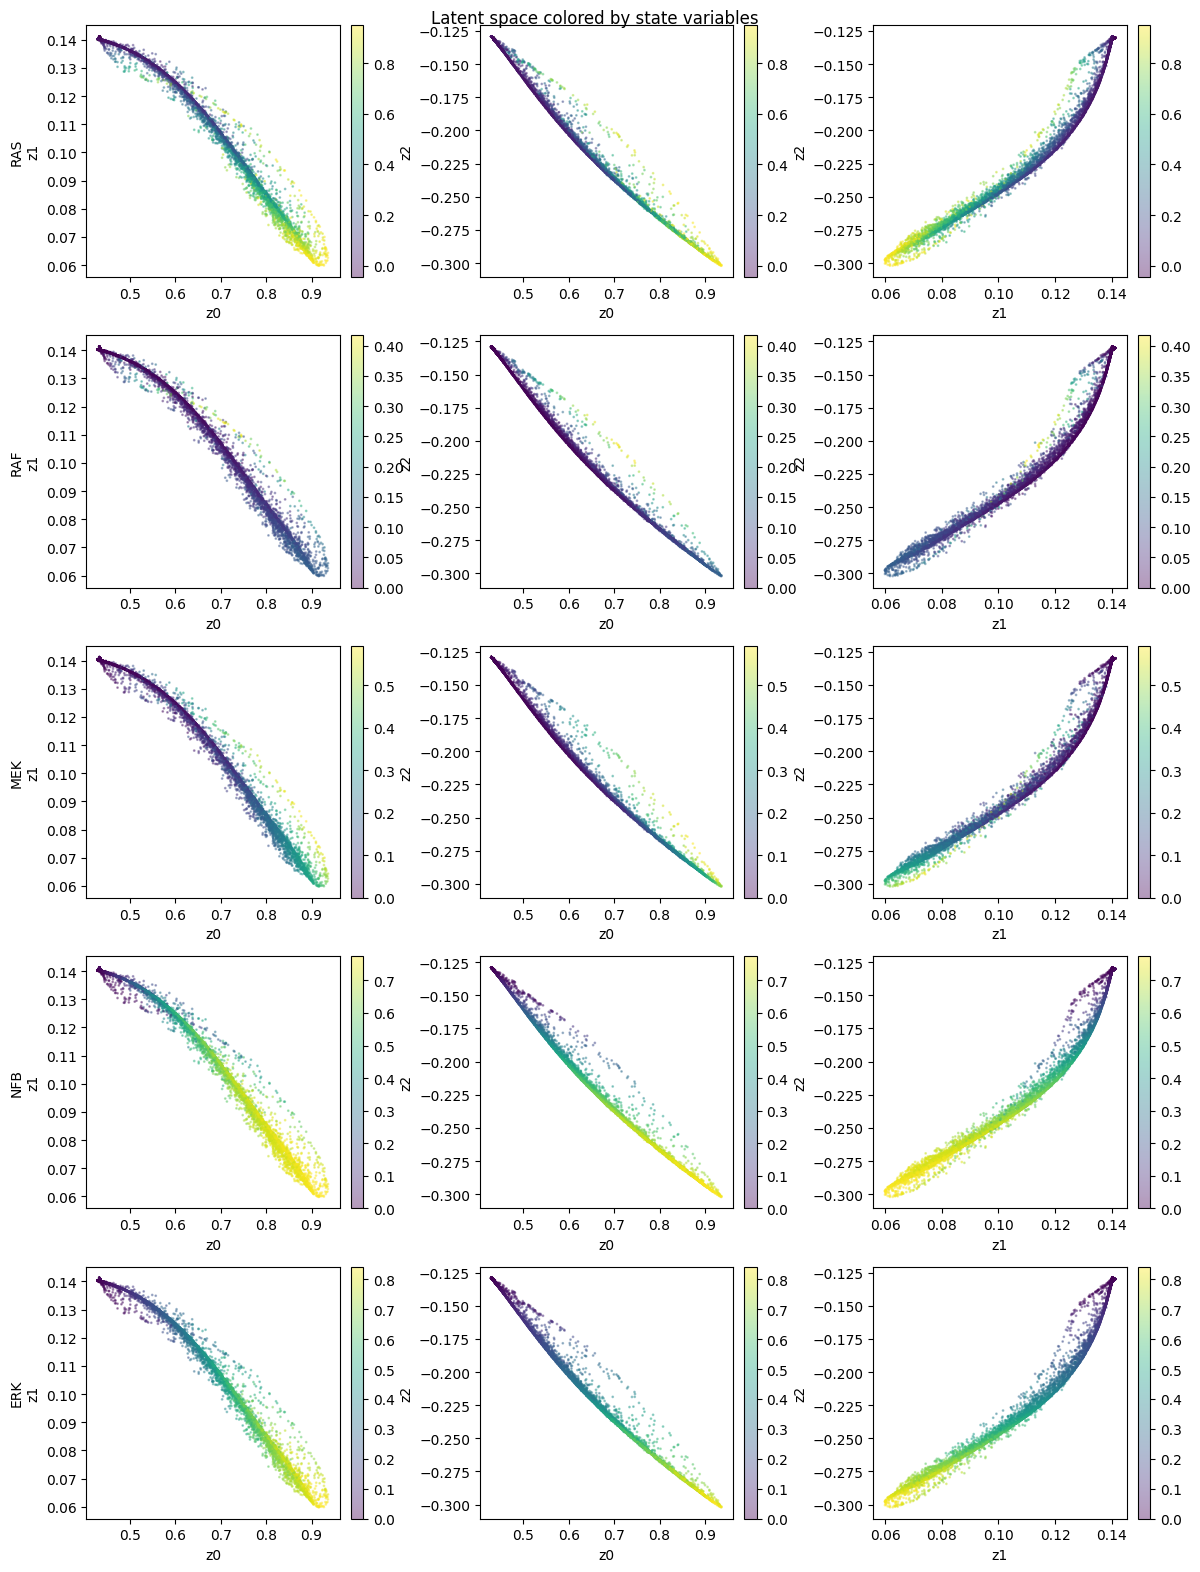

In [ ]:
result.figures["latent_colored_by_state"]

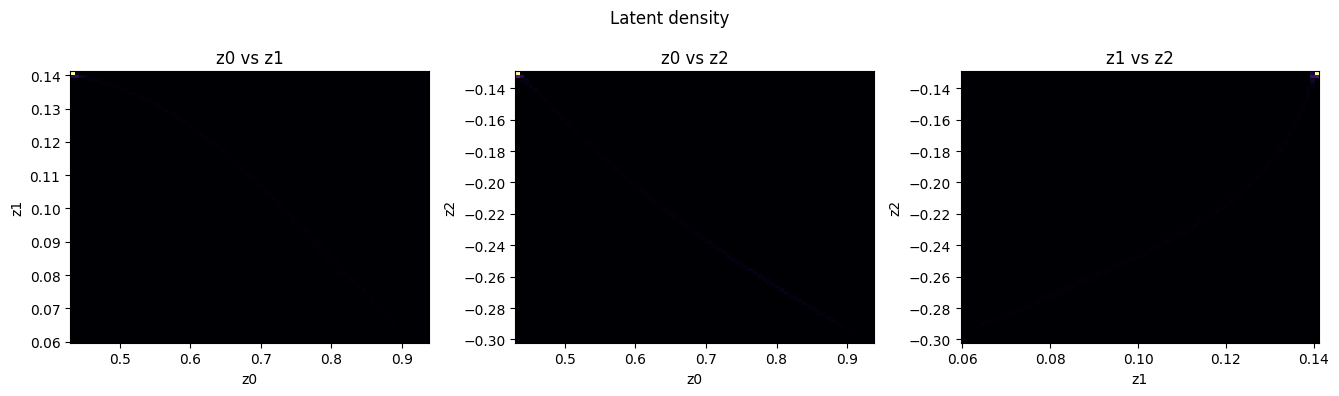

In [ ]:
result.figures["latent_density"]

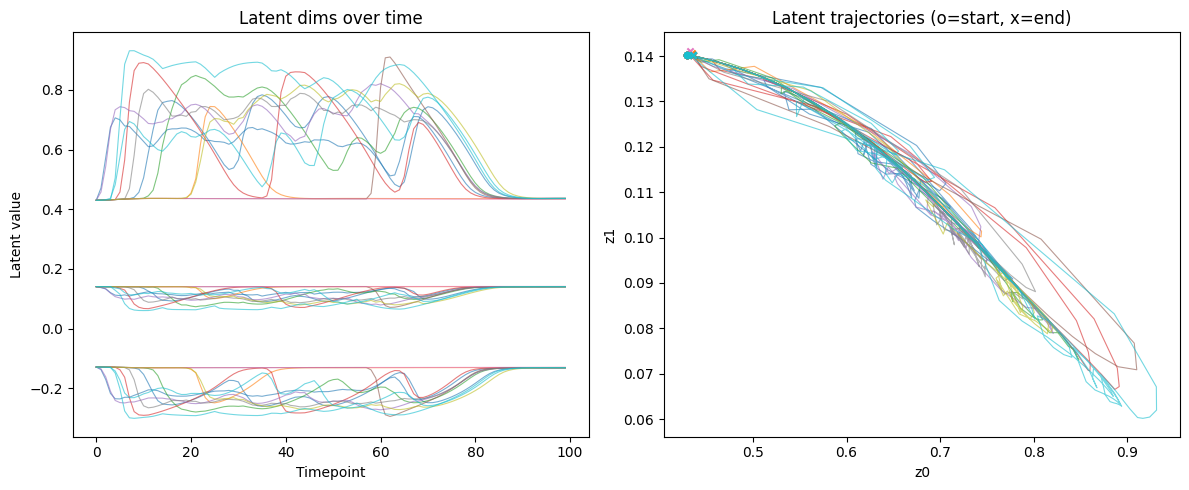

In [ ]:
result.figures["latent_trajectories"]

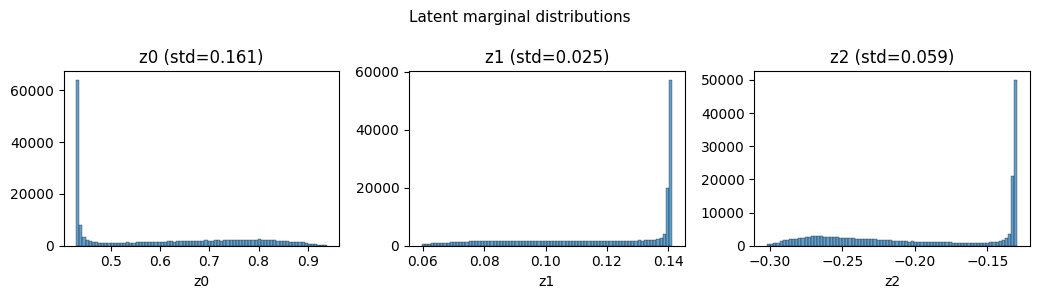

In [ ]:
result.figures["latent_marginals"]

---
# Save outputs

In [ ]:
OUTPUT_DIR = f"results/{EXPERIMENT_NAME}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

start_str = train_start.strftime("%Y%m%d_%H%M%S")
model_save_path = os.path.join(OUTPUT_DIR, f"model_{start_str}.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "training_kwargs": training_kwargs,
    "train_start": train_start.isoformat(),
    "train_elapsed_s": train_elapsed,
    "device": str(device),
}, model_save_path)
print(f"Model saved to {model_save_path}")

result.save(OUTPUT_DIR)
print(f"Evaluation saved to {OUTPUT_DIR}/")

Model saved to results/ae_states/model_20260317_113736.pt
Evaluation saved to results/ae_states/


---
# Notes

*Write observations here after running the experiment.*